# Data Set Up and Cleaning

In [14]:
# Importing necessary tools:
import zipfile
import os
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc, recall_score, roc_auc_score,
    ConfusionMatrixDisplay,
    accuracy_score
)

In [2]:
# Initial review of dataset:
zip_path = "/Users/seanrampersad/downloads/breast_cancer_wisconsin_diagnostic.zip"
extract_path = "data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".data") or file.endswith(".csv"):
            data_file = os.path.join(root, file)

columns = [
    "id","diagnosis",
    "radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean",
    "compactness_mean","concavity_mean","concave_points_mean","symmetry_mean","fractal_dimension_mean",
    "radius_se","texture_se","perimeter_se","area_se","smoothness_se",
    "compactness_se","concavity_se","concave_points_se","symmetry_se","fractal_dimension_se",
    "radius_worst","texture_worst","perimeter_worst","area_worst","smoothness_worst",
    "compactness_worst","concavity_worst","concave_points_worst","symmetry_worst","fractal_dimension_worst"
]

df = pd.read_csv(data_file, header=None, names=columns)

df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
## Although source indicated there are no missing values, we can confirm for this and duplicate entries via:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


--- Outlier Count Per Feature ---
area_se                    65
radius_se                  38
perimeter_se               38
area_worst                 35
smoothness_se              30
fractal_dimension_se       28
compactness_se             28
symmetry_se                27
area_mean                  25
fractal_dimension_worst    24
symmetry_worst             23
concavity_se               22
texture_se                 20
concave_points_se          19
concavity_mean             18
radius_worst               17
compactness_worst          16
compactness_mean           16
fractal_dimension_mean     15
perimeter_worst            15
symmetry_mean              15
radius_mean                14
perimeter_mean             13
concavity_worst            12
concave_points_mean        10
smoothness_worst            7
texture_mean                7
smoothness_mean             6
texture_worst               5
dtype: int64

Total Outlier Data Points: 608


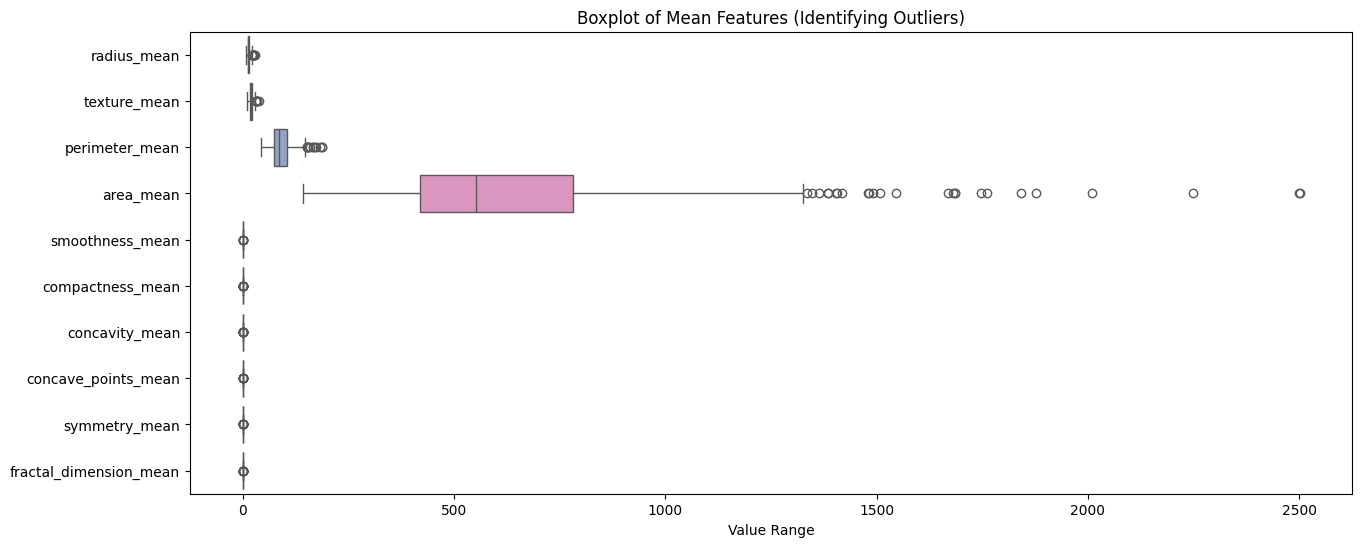

In [4]:
# Reviewing dataset for outliers using IQR method
# Cases for outliers are maintained as they may represent clinically significant cases

Q1 = df.iloc[:, 2:].quantile(0.25)
Q3 = df.iloc[:, 2:].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = (df.iloc[:, 2:] < (Q1 - 1.5 * IQR)) | (df.iloc[:, 2:] > (Q3 + 1.5 * IQR))
outlier_counts = outlier_mask.sum()

## More of a numeric visulization, however can be removed
print("--- Outlier Count Per Feature ---")
print(outlier_counts[outlier_counts > 0].sort_values(ascending=False))

total_outliers = outlier_counts.sum()
print(f"\nTotal Outlier Data Points: {total_outliers}")

## Boxplot visualization of outliers
plt.figure(figsize=(15, 6))
sns.boxplot(data=df.iloc[:, 2:12], orient="h", palette="Set2")
plt.title("Boxplot of Mean Features (Identifying Outliers)")
plt.xlabel("Value Range")
plt.show()

This plot shows that the area_mean consists of several outliers for the area_mean. Generally, these data points would be removed from the training model as it would be considered a bias, however cancerous tumors are expected to have significantly different area means as they grow faster. The perimiter_mean also shows a slight variation, however as noted, these data points are considered clinically significant. Therefore, given the significance of the outliers and the use of a scaler in the preprocessing of the data, no values have been removed.

# Exploratory Data Analysis

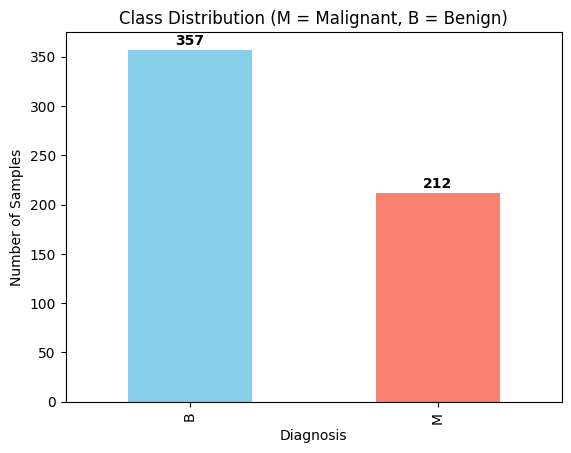

In [5]:
import matplotlib.pyplot as plt

counts = df["diagnosis"].value_counts()
counts.plot(kind="bar", color=['skyblue', 'salmon'])

for i, count in enumerate(counts):
    plt.text(i, count + 5, str(count), ha='center', fontweight='bold')

plt.title("Class Distribution (M = Malignant, B = Benign)")
plt.ylabel("Number of Samples")
plt.xlabel("Diagnosis")
plt.show()

There are 357 Benign (B) and 212 Malignant (M) samples, resulting in a slight class imbalance.

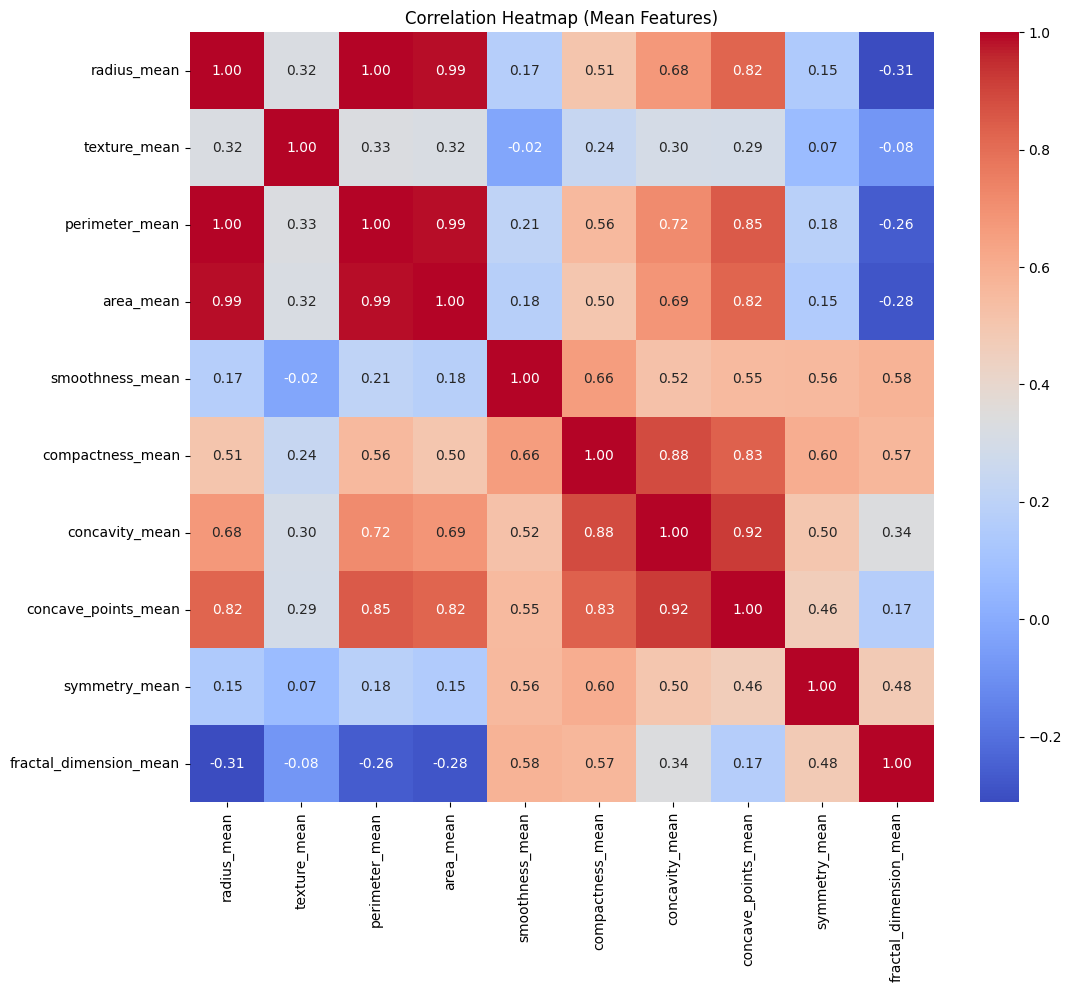

In [6]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.iloc[:, 2:12].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap (Mean Features)")
plt.show()

Strongest Relationships:
- Area, Radius, and Perimeter - this is expected as if the radius increases, the perimeter and area would increase as well given that cells are generally circular


# Preprocessing

In [7]:
label_e = LabelEncoder()
df['diagnosis'] = label_e.fit_transform(df['diagnosis'])

X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Advanced Model & Results

In [15]:

best_estimators = {
    'Logistic Regression': LogisticRegression(C=1, solver='liblinear', random_state=42).fit(X_train_scaled, y_train),
    'Random Forest': RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42).fit(X_train_scaled, y_train),
    'SVM': SVC(C=10, kernel='rbf', probability=True, random_state=42).fit(X_train_scaled, y_train)
}

def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    
    accuracy = accuracy_score(y, y_pred)
    sensitivity = recall_score(y, y_pred) # Same as Recall
    specificity = tn / (tn + fp)
    auc_roc = roc_auc_score(y, y_proba)
    
    return [accuracy, sensitivity, specificity, auc_roc, fn, fp]
log_reg = best_estimators['Logistic Regression']


rf_default = RandomForestClassifier(random_state=42).fit(X_train_scaled, y_train)

rf_tuned = best_estimators['Random Forest']

svm_model = best_estimators['SVM']

data = {
    "Logistic Regression (Baseline)": evaluate_model(log_reg, X_test_scaled, y_test),
    "Random Forest (Default)": evaluate_model(rf_default, X_test_scaled, y_test),
    "Random Forest (Tuned)": evaluate_model(rf_tuned, X_test_scaled, y_test),
    "SVM": evaluate_model(svm_model, X_test_scaled, y_test)
}

results_df = pd.DataFrame.from_dict(data, orient='index', 
                                    columns=['Accuracy', 'Sensitivity', 'Specificity', 'AUC-ROC', 'False Negatives', 'False Positives'])

fmt = {'Accuracy': '{:.2%}', 'Sensitivity': '{:.2%}', 'Specificity': '{:.2%}', 'AUC-ROC': '{:.4f}', 'False Negatives': '{:0.0f}', 'False Positives': '{:0.0f}'}
print("--- Model Performance Comparison ---")
print(results_df.style.format(fmt))
print(results_df) 

--- Model Performance Comparison ---
                                Accuracy  Sensitivity  Specificity   AUC-ROC  \
Logistic Regression (Baseline)  0.973684     0.952381     0.986111  0.996032   
Random Forest (Default)         0.973684     0.928571     1.000000  0.992890   
Random Forest (Tuned)           0.964912     0.904762     1.000000  0.994213   
SVM                             0.973684     0.928571     1.000000  0.992725   

                                False Negatives  False Positives  
Logistic Regression (Baseline)                2                1  
Random Forest (Default)                       3                0  
Random Forest (Tuned)                         4                0  
SVM                                           3                0  


# Hypertuning

In [16]:
models = {
    'Logistic Regression': (LogisticRegression(), {'C': [0.1, 1, 10]}),
    'SVM': (SVC(probability=True), {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']}),
    'Random Forest': (RandomForestClassifier(), {'n_estimators': [100, 200], 'max_depth': [None, 10, 20]})
}

best_estimators = {}

for name, (model, params) in models.items():
    grid = GridSearchCV(model, params, cv=StratifiedKFold(10), scoring='recall', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    best_estimators[name] = grid.best_estimator_
    print(f"Best params for {name}: {grid.best_params_}")

Best params for Logistic Regression: {'C': 1}
Best params for SVM: {'C': 10, 'kernel': 'rbf'}
Best params for Random Forest: {'max_depth': 20, 'n_estimators': 100}


# Evaluation and Threshold Tuning

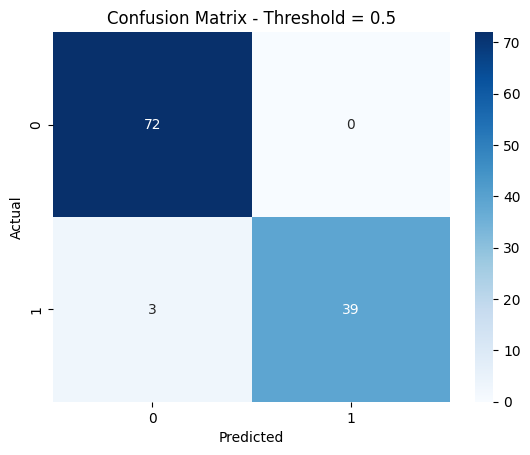

In [17]:
best_model = best_estimators['SVM']
y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]


sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Threshold = 0.5')
plt.show()

This graph shows that out of 114 patients:
    - 3 False Negatives - These patients could have been incorrectly misdiagnosed and therefore missed the opportunity to be treated, resulting in scenarios where their disease worsens. 
    - 0 false positives - No patients would receive unnecessary biopsies or treatments
    - 96% Recall

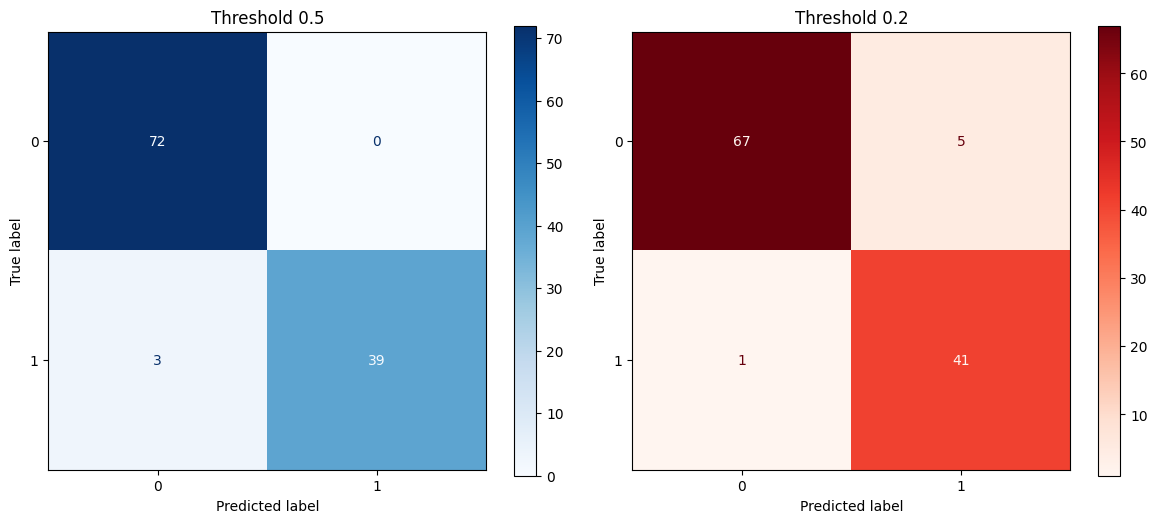

In [20]:
svm_advanced = SVC(
    C=10, 
    kernel='rbf', 
    probability=True, 
    random_state=42
)

svm_advanced.fit(X_train_scaled, y_train)

y_probs = svm_advanced.predict_proba(X_test_scaled)[:, 1]
y_pred_suspicious = (y_probs >= 0.2).astype(int)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

y_pred_default = svm_advanced.predict(X_test_scaled)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_default, ax=ax[0], cmap='Blues')
ax[0].set_title("Threshold 0.5")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_suspicious, ax=ax[1], cmap='Reds')
ax[1].set_title("Threshold 0.2")

plt.tight_layout()
plt.show()


If we decrease the threshold to 0.2 from 0.5, it would result in a higher amount of false positives, but fewer false negatives.